<a href="https://colab.research.google.com/github/HMS-Cleveland/Questionary_logist/blob/my/%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%92_%E9%99%84%E5%B8%A62%E4%B8%AA%E6%82%A3%E7%99%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # 添加这行导入语句
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import shap
import time

# 其余代码保持不变...

# ------------------------------------------------------------------
# 1. 非线性逻辑回归模型训练
# ------------------------------------------------------------------
# 1. 数据加载与预处理
# 1. 多读一列（原来 usecols 到 12，现在把 13 也加进来）
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]   # 13 是新增标签列
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']   # 两列都保留

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)
#data.replace(9, np.nan, inplace=True)
#data = data.dropna().copy()  # 删除含缺失值的行


# 精细化缺失值处理：年龄分层的9保留，其他特征的9替换为NaN
print("=== 数据基本信息 ===")
print(f"总样本数: {len(data)}")

# 定义需要处理缺失值的列（年龄分层除外）
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                      'first_birth', 'num_of_first_degree_cancer',
                      'breast_surgery', 'hormone_therapy']

data_processed = data.copy()
for col in cols_with_missing_9:
    data_processed[col] = data_processed[col].replace(9, np.nan)

# 构造标签
data_processed['diagnosis'] = (data_processed['diagnosis_12'] | data_processed['diagnosis_13']).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

print(f"标签分布 - 阴性: {sum(data_processed['diagnosis'] == 0)}, 阳性: {sum(data_processed['diagnosis'] == 1)}")
print(f"阳性率: {data_processed['diagnosis'].mean():.3f}")

# 检查各特征缺失值情况
print("\n=== 缺失值统计 ===")
missing_info = data_processed.isnull().sum()
for col, count in missing_info[missing_info > 0].items():
    print(f"{col}: {count}个缺失值 ({count/len(data_processed)*100:.1f}%)")

# ------------------------------------------------------------------
# 2. 特征工程与数据分割
# ------------------------------------------------------------------

X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']

# 分层分割数据
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

print(f"\n=== 数据分割结果 ===")
print(f"训练集: {X_train.shape[0]} 样本, 阳性比例: {y_train.mean():.3f}")
print(f"验证集: {X_val.shape[0]} 样本, 阳性比例: {y_val.mean():.3f}")
print(f"测试集: {X_test.shape[0]} 样本, 阳性比例: {y_test.mean():.3f}")

# ------------------------------------------------------------------
# 3. 改进的特征预处理管道
# ------------------------------------------------------------------

# 定义特征类型
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']  # 无序分类变量
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']  # 二分类变量

# 为有序变量定义类别顺序
age_categories = [['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']]
density_categories = [['1', '2', '3', '4']]
bmi_categories = [['1', '2', '3', '4']]
cancer_relatives_categories = [['0', '1', '2']]

# 使用ColumnTransformer构建更合理的预处理管道
preprocessor = ColumnTransformer(
    transformers=[
        # 有序变量：用中位数填充缺失值，然后进行序数编码
        ('ordinal', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('encoder', OrdinalEncoder(
                categories=age_categories + density_categories + bmi_categories + cancer_relatives_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ))
        ]), ordinal_features),

        # 无序变量：用众数填充缺失值，然后进行OneHot编码
        ('nominal', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore'))
        ]), nominal_features),

        # 二分类变量：用众数填充缺失值
        ('binary', SimpleImputer(strategy='most_frequent'), binary_features)
    ],
    remainder='passthrough'
)

# 3. 应用SMOTE过采样（仅训练集）
#smote = SMOTE(sampling_strategy='auto', random_state=42)
#X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res = X_train
y_train_res = y_train

# 使用imblearn的Pipeline以兼容SMOTE
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # 降低多项式次数防止过拟合
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        penalty='l2',
        C=0.008,  # 调整正则化强度
        solver='lbfgs',
        max_iter=5000,
        class_weight='balanced',  # 与SMOTE结合使用
        random_state=42
    ))
])
# 5. 训练模型
model_pipeline.fit(X_train_res, y_train_res)

# 6. 阈值优化（最大化灵敏度）
val_probs = model_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.1, 1, 50)  # 重点考察低阈值区间
best_recall = 0
best_thresh = 0.5

for thresh in thresholds:
    y_val_pred = (val_probs > thresh).astype(int)
    recall = recall_score(y_val, y_val_pred)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"最优阈值: {best_thresh:.3f} (验证集灵敏度={best_recall:.3f})")

# 7. 测试集评估
test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_pred_optim = (test_probs > 0.4).astype(int)   #0.38

print("\n【测试集性能报告】")
print(classification_report(y_test, test_pred_optim, target_names=["低风险", "高风险"]))
print(f"测试集AUC = {roc_auc_score(y_test, test_probs):.3f}")

# 计算特异性（真阴性率）
tn, fp, fn, tp = confusion_matrix(y_test, test_pred_optim).ravel()
specificity = tn / (tn + fp)
sensitivity = recall_score(y_test, test_pred_optim, pos_label=1)
print(f"灵敏度 = {sensitivity:.3f}, 特异性 = {specificity:.3f}")


# 9. 个体风险预测示例
person = pd.DataFrame([[1, 60, 3, 1, 28.5, 1, 0, 1, 0]], columns=X.columns)
person_prob = model_pipeline.predict_proba(person)[0][1]
print(f"\n个体预测结果: 高风险概率 = {person_prob:.3f}")

import numpy as np
import pandas as pd
from itertools import combinations
from math import factorial
from joblib import Parallel, delayed
from tqdm import tqdm

# 0. 统一背景 & 全局样本池
COMMON_BG = X_train_res.sample(500, random_state=42)
bg_vals    = COMMON_BG.values
X_global  = X_test.sample(500, random_state=123)   # 100 条
#X_global  = X_test
features  = X.columns
M = X.shape[1]
def pred_fn(X_arr):
    """统一 CPU 预测接口"""
    X_df = pd.DataFrame(X_arr, columns=features)
    return model_pipeline.predict_proba(X_df)[:, 1]

def exact_shap_one(xser):
    """
    xser: pd.Series 长度 M
    返回: 长度 M 的 numpy 数组，真正的 Exact SHAP 值
    """
    x = xser.values.astype(float)
    phis = np.zeros(M)
    # 预先把背景数据拼成矩阵，方便后面掩码
    for i in range(M):
        # 对所有不含 i 的子集 S
        for size in range(0, M):           # size 从 0 到 M-1
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)
                # 构造两个矩阵：bg 中 S 固定为 x[S]，其余保持 bg 原值
                mask = np.ones_like(bg_vals, dtype=bool)
                mask[:, S] = False          # 这些列要替换成 x
                X_S  = bg_vals.copy()
                X_Si = bg_vals.copy()
                # 把 S 里的特征换成 x
                X_S[:, S]  = x[S]
                X_Si[:, S] = x[S]
                # 再把 i 也换掉
                X_Si[:, i] = x[i]
                # 预测
                f_S  = pred_fn(X_S).mean()
                f_Si = pred_fn(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis


# ========== 2. 跑完全局 100 条 ==========
# ---- 2.1 Exact ----
times, shapley_mat = {}, {}
start = time.time()
shapley_mat['Exact'] = np.array(
    Parallel(n_jobs=8)(delayed(exact_shap_one)(X_global.iloc[i])
                       for i in tqdm(range(len(X_global)), desc='Exact')))
times['Exact'] = time.time() - start

# ---- 2.2 全局重要性 ----
global_exact = np.abs(shapley_mat['Exact']).mean(axis=0)   # (9,)


# ========== 3. KernelSHAP 同批样本 ==========
import shap
explainer = shap.KernelExplainer(pred_fn, COMMON_BG, link='identity')
sv_k_matrix = explainer.shap_values(X_global, nsamples=64)  # (100,9)
global_kernel = np.abs(sv_k_matrix).mean(axis=0)

# ========== 4. 结果对比 ==========
print("================ 全局特征重要性对比 ================")
print(f"{'特征':<30} | {'KernelSHAP':>12} | {'Exact-并行':>12} | 差值")
print("-" * 60)
for f, gk, ge in zip(features, global_kernel, global_exact):
    print(f"{f:<30} | {gk:>12.5f} | {ge:>12.5f} | {abs(gk-ge):.5e}")

print("\n汇总误差")
print(f"MAE  = {np.abs(global_kernel - global_exact).mean():.5e}")
print(f"RMSE = {np.sqrt(np.mean((global_kernel - global_exact)**2)):.5e}")


# 1. 画 Summary Plot（点图）
plt.figure(figsize=(8, 6))
shap.summary_plot(
    sv_k_matrix,                      # KernelSHAP 值 (100,9)
    X_global,                         # 对应 100 条样本
    feature_names=features,
    plot_type="dot",                  # 点图
    color='coolwarm',                 # 颜色梯度
    show=False                        # 不自动弹窗
)
plt.title('Shapley Value Summary Plot')
plt.tight_layout()
plt.show()


# ========== 7. 带数值标注的 SHAP 条形图 ==========
# 计算全局重要性（|SHAP| 均值）
global_imp = np.abs(sv_k_matrix).mean(axis=0)  # shape: (9,)

# 按重要性降序排序
sorted_idx = np.argsort(global_imp)[::-1]  # [::-1] 实现降序
sorted_features = [features[i] for i in sorted_idx]
sorted_values = global_imp[sorted_idx]

# 绘制条形图
plt.figure(figsize=(8, 6))
bars = plt.barh(sorted_features, sorted_values, color='steelblue', edgecolor='black')

# 添加数值标注
for i, (bar, value) in enumerate(zip(bars, sorted_values)):
    # 标注在条形右侧，略微偏移
    plt.text(
        value + 0.001,  # x 位置：条形末端 + 偏移量
        i,              # y 位置：条形中心线
        f'{value:.4f}', # 文本：保留4位小数
        va='center',    # 垂直对齐：居中
        ha='left',      # 水平对齐：左对齐
        fontsize=9,     # 字体大小
        color='black'   # 字体颜色
    )

# 调整 x 轴范围，为标签留出空间
plt.xlim(0, sorted_values.max() * 1.15)  # 右边多留15%空白

# 添加标题和标签
plt.xlabel('mean(|SHAP value|)', fontsize=12)
plt.title('Feature Importance with Values', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 1. 单变量 PDP ── 主效应方向
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model_pipeline,                # 你的完整 pipeline
    X_train,                       # 训练集即可
    features=['first_birth'],
    kind='average',                # 平均掉交互
    subsample=1000, random_state=42,
    grid_resolution=50             # 更平滑
)
plt.suptitle('PDP: 一级亲属患癌人数 → 预测风险（主效应）', fontsize=14)
plt.tight_layout()
plt.show()


# 选择要分析的特征（例如'age'）
feature_name = 'num_of_first_degree_cancer'
feature_index = X.columns.get_loc(feature_name)

# 使用SHAP内置函数绘制散点图
shap.dependence_plot(
    feature_index,
    sv_k_matrix,
    X_global,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP值散点图 - {feature_name}")
plt.tight_layout()
plt.show()

最优阈值: 0.100 (验证集灵敏度=0.995)

【测试集性能报告】
              precision    recall  f1-score   support

         低风险       0.99      0.42      0.59     27136
         高风险       0.05      0.85      0.09       930

    accuracy                           0.44     28066
   macro avg       0.52      0.64      0.34     28066
weighted avg       0.96      0.44      0.58     28066

测试集AUC = 0.708
灵敏度 = 0.851, 特异性 = 0.423

个体预测结果: 高风险概率 = 0.100


12和13关系诊断报告

1. 交叉表（行=12，列=13）：
        13=0  13=1      总计
12=0  271355  2114  273469
12=1       0  7191    7191
总计    271355  9305  280660

2. 关键诊断指标：
   - 样本总数: 280660
   - 13=1的样本数: 9305
   - 12=1的样本数: 7191
   - ❗ 包含率 (13=1 → 12=1): 77.3%

3. 关系自动诊断：
   ❌ 部分重叠关系（包含率=77.3%）
   解释：两变量相关但独立

4. 关键证据样本（13=1但12=0，共2114个）：
      age_5_years  num_of_first_degree_cancer  BIRADS_breast_density
832             1                           1                      2
1993            1                           0                      3
2257            1                           0                      3


/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missi

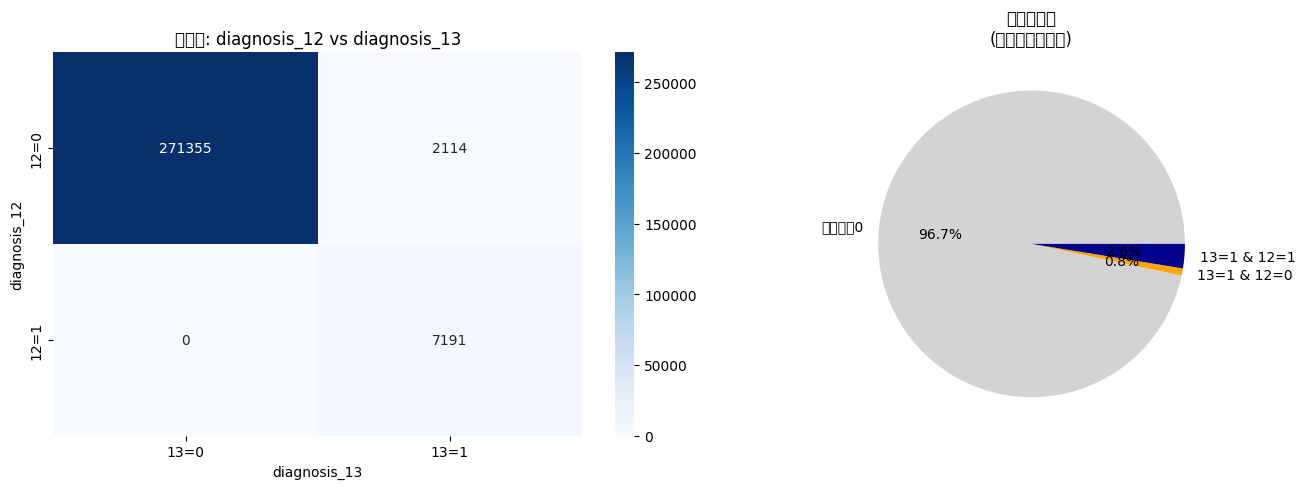


最终决策建议
❌ 数据问题：12和13不是包含关系，需重新定义数据字典


In [ ]:
# ==================== 诊断12和13关系的完整代码 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取原始数据（不处理标签，保留原始状态）
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)

print("="*60)
print("12和13关系诊断报告")
print("="*60)

# 2. 构建核心诊断工具：交叉表
cross_tab = pd.crosstab(
    data['diagnosis_12'],
    data['diagnosis_13'],
    margins=True,
    margins_name='总计'
)
cross_tab.index = ['12=0', '12=1', '总计']
cross_tab.columns = ['13=0', '13=1', '总计']
print("\n1. 交叉表（行=12，列=13）：")
print(cross_tab)

# 3. 计算关键指标：包含率和互斥率
total_samples = len(data)
cancer_13 = data['diagnosis_13'] == 1
cancer_12 = data['diagnosis_12'] == 1

# 黄金指标：当13=1时，12也=1的比例
containment_rate = (cancer_13 & cancer_12).sum() / cancer_13.sum()
print(f"\n2. 关键诊断指标：")
print(f"   - 样本总数: {total_samples}")
print(f"   - 13=1的样本数: {cancer_13.sum()}")
print(f"   - 12=1的样本数: {cancer_12.sum()}")
print(f"   - ❗ 包含率 (13=1 → 12=1): {containment_rate:.1%}")

# 4. 自动判断关系类型
print(f"\n3. 关系自动诊断：")
if containment_rate == 1.0:
    print("   ✅ 完全包含关系")
    print("   解释：13是12的超集（13包含12）")
    print("   建议：13=浸润性癌+DCIS, 12=仅浸润性癌")
elif containment_rate > 0.95:
    print(f"   ⚠️ 近似包含关系（包含率={containment_rate:.1%}）")
    print("   建议：检查剩余{cancer_13.sum() - (cancer_13 & cancer_12).sum()}个样本是否为数据错误")
elif containment_rate > 0.5:
    print(f"   ❌ 部分重叠关系（包含率={containment_rate:.1%}）")
    print("   解释：两变量相关但独立")
else:
    print(f"   ❌ 无包含关系（包含率={containment_rate:.1%}）")
    print("   解释：12和13是独立变量")

# 5. 证据性样本抽查（如果存在互斥样本）
mutual_exclusion = (cancer_13 & ~cancer_12)
if mutual_exclusion.sum() > 0:
    print(f"\n4. 关键证据样本（13=1但12=0，共{mutual_exclusion.sum()}个）：")
    examples = data[mutual_exclusion].head(3)
    print(examples[['age_5_years', 'num_of_first_degree_cancer', 'BIRADS_breast_density']])
else:
    print(f"\n4. 关键证据：不存在13=1且12=0的样本")

# 6. 可视化关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6.1 交叉表热力图
sns.heatmap(cross_tab.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('交叉表: diagnosis_12 vs diagnosis_13')
axes[0].set_xlabel('diagnosis_13')
axes[0].set_ylabel('diagnosis_12')

# 6.2 包含关系示意图
labels = ['两者都为0', '13=1 & 12=0', '13=1 & 12=1']
sizes = [
    (~cancer_13 & ~cancer_12).sum(),
    mutual_exclusion.sum(),
    (cancer_13 & cancer_12).sum()
]
colors = ['lightgray', 'orange', 'darkblue']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('关系示意图\n(橙色区域是关键)')

plt.tight_layout()
plt.show()

# 7. 最终决策建议
print("\n" + "="*60)
print("最终决策建议")
print("="*60)
if containment_rate == 1.0:
    decision = "✅ 采用方案：13=患癌（总标签），12=浸润性癌（亚型）"
    print(decision)
    print("   后续分析：在患癌人群中，用12区分浸润性癌和DCIS")
elif containment_rate > 0.95:
    print("⚠️ 需人工核查例外样本后，再决定标签定义")
else:
    print("❌ 数据问题：12和13不是包含关系，需重新定义数据字典")